In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from neurodiffeq.conditions import IVP
from neurodiffeq import diff
from neurodiffeq.generators import Generator1D
from neurodiffeq.solvers import Solver1D, Solution1D, BundleSolution1D
from neurodiffeq.networks import FCNN
from neurodiffeq.conditions import BundleIVP 
import torch
import os
from delta_solver_mg_2 import DeltaSolver
from utils_2 import CustomCondition, f_R_reparams, _shape_manager
import yaml

from scipy.stats import qmc
from neurodiffeq.solvers import BundleSolver1D
from neurodiffeq.generators import PredefinedGenerator

from scipy.constants import c as c_ms

In [ ]:
H_0 = 67
h = H_0 / 100
Om_r_0 = 5.38 * 10 ** (-5)
Om_m_0 = 0.1
Om_L_0 = 1 - Om_m_0 - Om_r_0
c = c_ms / 1000

b =0.1
k = 0.2 
k_val = k*h
Lambda = 3 * (H_0 ** 2) * (1 - Om_m_0) / c**2


# Parámetros para las redes
z_0 = 20
z_f = 0.0
b_max = 5.0


# Parámetros para el solver
a_0 = 1 / 1001
a_f = 1
N_0 = np.log(a_0)
N_f = np.log(a_f)
n_0 = abs(N_0)
N_p_0 = N_0 / n_0

N_p_f = N_f / n_0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


Llamar a la red de Augusto:

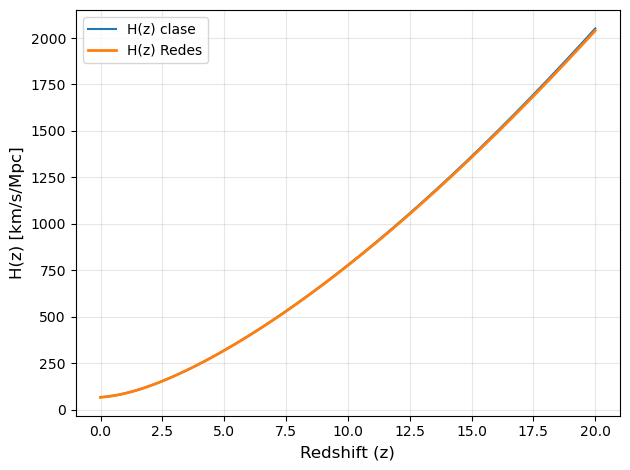

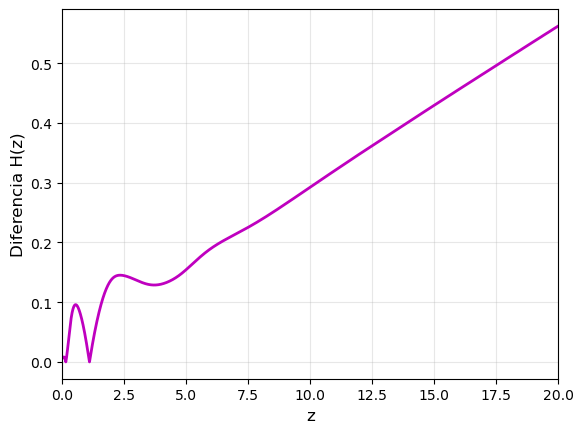

In [71]:

model = 'Hu-Sawicki'
path = f'/home/javier-pineau/Escritorio/Tesis/Códigos Augusto/f_R_nets_for_multiuse/{model}_nets'

with open(f'{path}/saved_config.yaml') as yaml_file_f_R:
    try:
        Config_f_R = yaml.safe_load(yaml_file_f_R)
    except yaml.YAMLError as exc:
        print(exc)

# Set the range of the independent variable:

z_rescale = z_0

z_prime_min = 0.0
z_prime_max = 1.0
z_min = z_prime_min
z_max = z_rescale * z_prime_max

# Set the range of the parameters of the bundle:
b_prime_min = float(Config_f_R['b_prime_min'])
b_prime_max = 1.0
b_max = Config_f_R['b_max']
b_min = b_prime_min * b_max

Om_m_0_min = Config_f_R['Om_m_0_min']
Om_m_0_max = Config_f_R['Om_m_0_max']

# Set neural network parameters and renormalizations:
alpha_nominator = Config_f_R['alpha_nominator']
alpha_denominator = Config_f_R['alpha_denominator']
alpha = alpha_nominator / alpha_denominator

# Cargar solo las redes necesarias para H(z)
nets = torch.load(f'{path}/nets_f_R.ph', map_location=torch.device('cpu'), weights_only=False)

f_R = f_R_reparams(z_0=z_0, b_prime_min=b_prime_min, b_max=b_max, alpha=alpha)

conditions = [
    CustomCondition(f_R.v_reparam),
    CustomCondition(f_R.r_prime_reparam)
 ]

r_prime_net_index = -1
v_net_index = 2

r_prime = BundleSolution1D([nets[r_prime_net_index]], [conditions[-1]])
v = BundleSolution1D([nets[v_net_index]], [conditions[0]])

def H(z, theta, **kwargs):
    """Función que calcula el parámetro de Hubble H(z)"""
    b, Om_m_0, H_0 = theta  
    
    z_prime = 1 - (z / z_rescale)
    b_prime = b / b_max

    if kwargs.pop('post', False):
        z_prime = z_prime * np.ones_like(b_prime)
        no_reshape = False
    else:
        shape, no_reshape = _shape_manager(z, b, Om_m_0)
        b_prime = b_prime * shape
        Om_m_0 = Om_m_0 * shape

    # --- DEVICE & DTYPE FIX: ensure all tensors are on the same device and dtype as the network ---
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    import torch
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)

    out = H_0 * np.sqrt(((1 - Om_m_0) / 2) * np.exp(r_prime_sol) / v_sol)

    if no_reshape:
        out = out[0][0]
    return out



z_examples = np.linspace(0, z_0, 10000) # Hay que hacer que coincida con los que uso para entrenar la red. 

theta_example = [b, Om_m_0, H_0]


H_values = H(z_examples, theta_example)

solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k)
solver_clase.z_ini_HS = z_0  

H_interp, Hprime_interp, r_interp = solver_clase.H_HS()


plt.plot(z_examples, H_0*H_interp(z_examples), '-', label='H(z) clase')
plt.plot(z_examples, H_values, linewidth=2, label='H(z) Redes')
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('H(z) [km/s/Mpc]', fontsize=12)
#plt.title(f' H(z)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
#plt.xlim(0, 0.5)
#plt.ylim(70, 150)

plt.tight_layout()
plt.savefig(f'H_z_Hu_Sawicki_0m={Om_m_0}_b={b}.png', dpi=300)
plt.show()

dif_H = 100 * np.abs((H_0*H_interp(z_examples) - H_values) / (H_0*H_interp(z_examples)))
plt.plot(z_examples, dif_H, 'm-', linewidth=2)
plt.xlabel('z', fontsize=12)
plt.ylabel('Diferencia H(z)', fontsize=12)
#plt.title('Diferencia H(z)')
plt.grid(True, alpha=0.3)
plt.xlim(0, z_0)
plt.savefig(f'Diferencia_H_z_Hu_Sawicki_0m={Om_m_0}_b={b}.png', dpi=300)
plt.show()

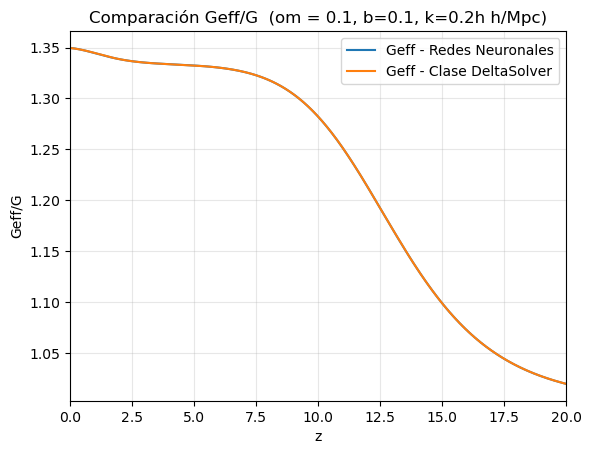

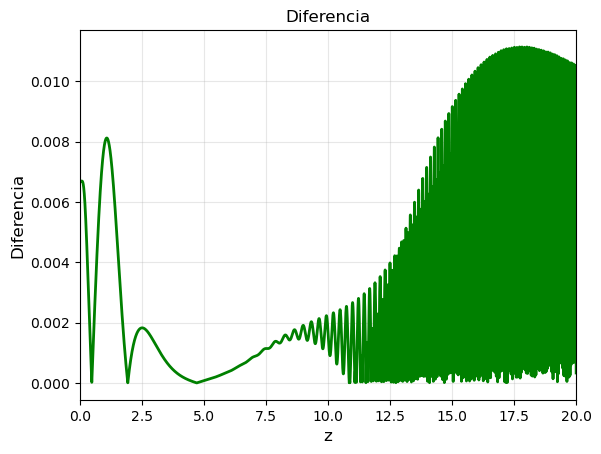

In [72]:
def Geff_G_func(z, k, b, Om_m_0, Lambda_val, debug=False, **kwargs):
    z_prime = 1 - (z / z_rescale)
    b_prime = b / b_max

    if kwargs.pop('post', False):
        z_prime = z_prime * np.ones_like(b_prime)
        no_reshape = False
    else:
        shape, no_reshape = _shape_manager(z, b, Om_m_0)
        b_prime = b_prime * shape
        Om_m_0 = Om_m_0 * shape

    # --- DEVICE & DTYPE FIX: ensure all tensors are on the same device and dtype as the network ---
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    import torch
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)

    r_prime_exp = np.exp(r_prime_sol)

    denomFR = 1.0 + (r_prime_exp * Lambda_val) / (Lambda_val * b)  

    FR = 1.0 - 2.0 / (b * (denomFR ** 2))
    FRR = 4.0 / (Lambda_val * b**2 * (denomFR ** 3))

    m = FRR / FR
    epsilon = (k_val**2) * (1.0 + z)**2 * m

    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)

    return Geff_over_G


Geff_class = solver_clase.Geff(z_examples, r_interp)

Geff_nets = Geff_G_func(z_examples, k, b, Om_m_0, Lambda)  #Guarda que acá cambié k_val por k*
Geff_interp_from_nets = interp1d(z_examples, Geff_nets, kind='cubic', fill_value="extrapolate")    

plt.plot(z_examples, Geff_nets, '-', label='Geff - Redes Neuronales')
plt.plot(z_examples, Geff_class, label='Geff - Clase DeltaSolver')

plt.xlabel('z')
plt.ylabel('Geff/G')
plt.title(f'Comparación Geff/G  (om = {Om_m_0}, b={b}, k={k}h h/Mpc)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, z_0)
plt.show()  


diferencia = 100 * np.abs((Geff_class - Geff_nets) / Geff_class)
plt.plot(z_examples, diferencia, 'g-', linewidth=2)

plt.xlabel('z', fontsize=12)
plt.ylabel('Diferencia', fontsize=12)
plt.title('Diferencia')
plt.grid(True, alpha=0.3)
plt.xlim(0, z_0)

plt.show()

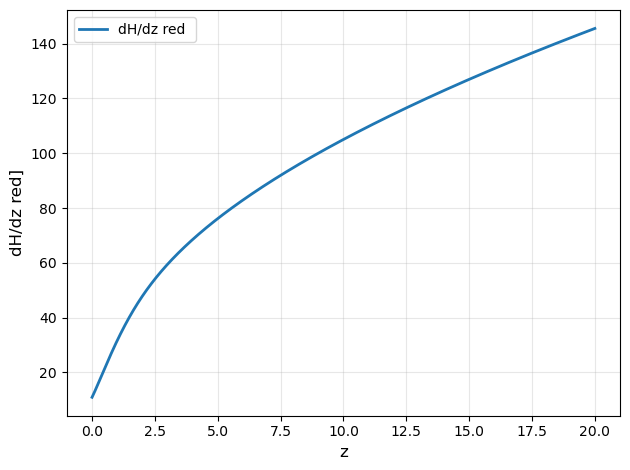

In [73]:
x_net_index = 0
x_condition = CustomCondition(f_R.x_reparam)
x = BundleSolution1D([nets[x_net_index]], [x_condition])

def dH_dz_red(z, theta):
    b, Om_m_0, H_0_local = theta

    z = np.asarray(z)
    z_prime = 1 - (z / z_rescale)
    b_prime = np.full_like(z, b / b_max)
    Om_m_0_arr = np.full_like(z, Om_m_0)

    # Ensure correct device and dtype for all network inputs
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    import torch
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0_arr)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)
    x_sol = x(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)

    dtype = r_prime_sol.dtype
    device = r_prime_sol.device

    r = torch.exp(r_prime_sol)
    b_tensor = torch.as_tensor(b_prime * b_max, dtype=dtype, device=device)
    Om_m_0_tensor = torch.as_tensor(Om_m_0_arr, dtype=dtype, device=device)
    z_tensor = torch.as_tensor(z, dtype=dtype, device=device)

    Gamma = (r + b_tensor) * (((r + b_tensor) ** 2) - 2.0 * b_tensor) / (4.0 * b_tensor * r)
    denom = z_tensor + 1.0

    dr_dz = - r * Gamma * x_sol / denom
    dv_dz = - v_sol * (x_sol * Gamma + 4.0 - 2.0 * v_sol) / denom

    coef1 = 0.25 * (1.0 - Om_m_0_tensor)
    coef2 = torch.sqrt(r / (2.0 * v_sol) * (1.0 - Om_m_0_tensor))

    dH = coef1 / coef2 * (dr_dz / v_sol - r * dv_dz / (v_sol ** 2))
    return dH.detach().cpu().numpy()

theta_example = [b, Om_m_0, H_0]

dH_net_values = H_0 * dH_dz_red(z_examples, theta_example)

plt.plot(z_examples, dH_net_values, label='dH/dz red ', linewidth=2)
plt.xlabel('z', fontsize=12)
plt.ylabel('dH/dz red]', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

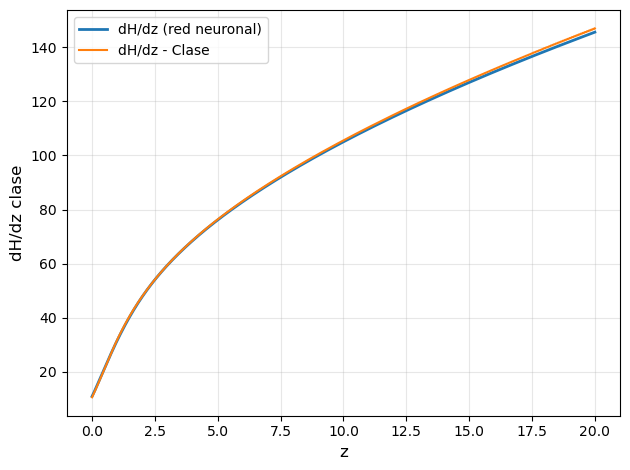

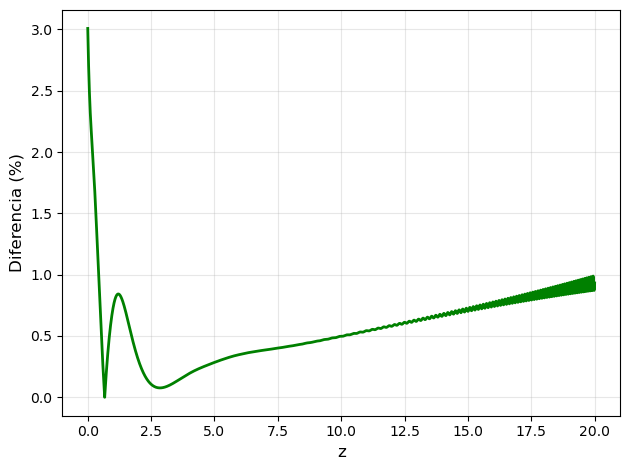

In [74]:
H_interp_class, Hprime_interp_class, r_interp_class = solver_clase.H_HS()
z_range_class = np.linspace(0, solver_clase.z_ini_HS, 10000)
H_class = H_interp_class(z_range_class) * H_0  
r_class = r_interp_class(z_range_class)
z_vec_class, x_vec_class, v_vec_class, r_vec_class = solver_clase.integ_HS()
v_interp_class = interp1d(z_vec_class, v_vec_class, bounds_error=False, fill_value="extrapolate")
v_class = v_interp_class(z_range_class)


dH_dz_clase_values =H_0* solver_clase.dH_dz(z=z_range_class, r=r_class, v=v_class, x=x_vec_class)
dH_dz_clase_values = np.asarray(dH_dz_clase_values)
dH_net_values = np.asarray(dH_net_values)


plt.plot(z_examples, dH_net_values, label='dH/dz (red neuronal)', linewidth=2)
plt.plot(z_range_class, dH_dz_clase_values, label='dH/dz - Clase')
plt.legend(fontsize=10)
plt.xlabel('z', fontsize=12)
plt.ylabel('dH/dz clase', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'dH_dz_Hu_Sawicki_om={Om_m_0}_b={b}.png', dpi=300)
plt.show()

dH_interp_class_to_examples = interp1d(z_range_class, dH_dz_clase_values, bounds_error=False, fill_value="extrapolate")

dH_dz_clase = dH_interp_class_to_examples(z_examples)


dif_dH_dz = 100 * np.abs((dH_dz_clase - dH_net_values) / dH_dz_clase)

plt.plot(z_examples, dif_dH_dz, 'g-', linewidth=2)
plt.xlabel('z', fontsize=12)
plt.ylabel('Diferencia (%)', fontsize=12)
#plt.title('Diferencia porcentual dH/dz', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'Diferencia_dH_dz_Hu_Sawicki_om={Om_m_0}_b={b}.png', dpi=300)
plt.show()


#### Acá defino la H y H prima de manera completa

Comparación de derivadas

<>:68: SyntaxWarning: invalid escape sequence '\L'
<>:68: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_64289/677597654.py:68: SyntaxWarning: invalid escape sequence '\L'
  plt.title('dH/dz redes + $\Lambda$CDM')


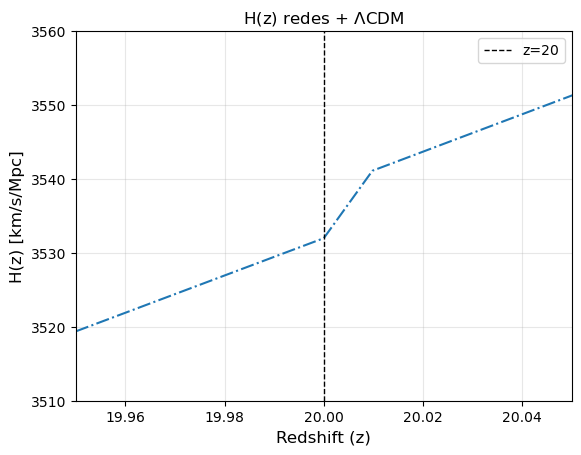

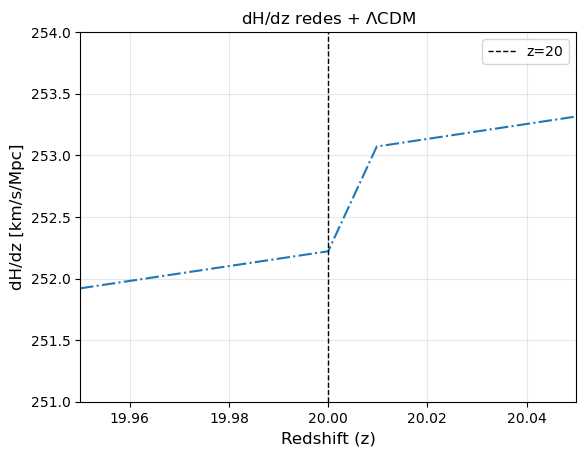

In [54]:
# Derivadas de red + expresión analítica de LCDM pegadas

def H_LCDM(a):
    inside = Om_L_0 + Om_m_0 / (a ** 3) + Om_r_0 / (a ** 4)
    return H_0 * np.sqrt(inside)

def dH_da_LCDM(a):
    numerator = -3.0 * Om_m_0 * (a ** (-4)) - 4 * Om_r_0 * (a ** (-5))
    raiz = np.sqrt(Om_L_0 + Om_m_0 / (a ** 3) + Om_r_0 / (a ** 4))
    dHda_ana = H_0 * numerator / (2 * raiz)
    return dHda_ana


z_lcdm = np.linspace(z_0, 1000, 100000)

dH_net_values =H_0* dH_dz_red(z_examples, theta_example)
da_dz = -1.0 / (1.0 + z_lcdm)**2

#LCDM

H_LCDM_segment = H_LCDM(1.0 / (1.0 + z_lcdm)) 
dH_dz_tramo_LCDM = dH_da_LCDM(1.0 / (1.0 + z_lcdm))*da_dz

#MG

H_MG_segment = H_values 
dH_dz_tramo_MG = dH_net_values 


z_comb = np.concatenate((z_examples, z_lcdm[1:]))
H_comb = np.concatenate((H_MG_segment, H_LCDM_segment[1:]))
dH_dz_comb = np.concatenate((dH_dz_tramo_MG, dH_dz_tramo_LCDM[1:]))

order = np.argsort(z_comb)
z_total = z_comb[order]
H_total = H_comb[order]
dH_dz_total = dH_dz_comb[order]

#sacar lo de abajo y ver qué pasa

mask = np.ones_like(z_total, dtype=bool)
z_clean = z_total #[mask]
H_clean = H_total#[mask]
dH_dz_clean = dH_dz_total#[mask]


plt.plot(z_total, H_total, '-.') #, label='H(z) redes + LCDM')
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('H(z) [km/s/Mpc]', fontsize=12)
plt.xlim(19.95, 20.05)
plt.ylim(3510, 3560)
plt.title('H(z) redes + $\\Lambda$CDM')
plt.axvline(x=20, color='black', linestyle='--', label = 'z=20', linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.savefig('H_redes_LCDM_Om=0.3_zoom.png', dpi=300)
plt.show()



plt.plot(z_total, dH_dz_total, '-.')# label='dH/dz mezcla redes + LCDM')
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('dH/dz [km/s/Mpc]', fontsize=12)

plt.xlim(19.95, 20.05)

plt.ylim(251,254)
plt.title('dH/dz redes + $\Lambda$CDM')

plt.grid(True, alpha=0.3)
plt.axvline(x=20, color='black', linestyle='--', label = 'z=20', linewidth=1)

plt.legend(fontsize=10)
plt.savefig('Hprima_redes_LCDM_Om=0.3_zoom.png', dpi=300)

plt.show()


<>:93: SyntaxWarning: invalid escape sequence '\O'
<>:177: SyntaxWarning: invalid escape sequence '\O'
<>:188: SyntaxWarning: invalid escape sequence '\O'
<>:93: SyntaxWarning: invalid escape sequence '\O'
<>:177: SyntaxWarning: invalid escape sequence '\O'
<>:188: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_18480/476176567.py:93: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f'Loss $\Omega_{{m0}}$ = {Om_m_0} k = {k}h, b= {b}')
/tmp/ipykernel_18480/476176567.py:177: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Comparación: $\Omega_{{m0}}$ ={Om_m_0}, k = {k}h, b = {b}")
/tmp/ipykernel_18480/476176567.py:188: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Diferencia porcentual $\Omega_{{m0}}$ ={Om_m_0}, k = {k}h, b = {b}")


Training Progress:   0%|          | 0/1000000 [00:00<?, ?it/s]

/tmp/ipykernel_18480/3579266623.py:16: RuntimeWarning: overflow encountered in exp
  r_prime_exp = np.exp(r_prime_sol)
/tmp/ipykernel_18480/3579266623.py:21: RuntimeWarning: overflow encountered in power
  FRR = 4.0 / (Lambda_val * b**2 * (denomFR ** 3))
/tmp/ipykernel_18480/3579266623.py:26: RuntimeWarning: divide by zero encountered in divide
  term = 1.0 / (3.0 + 1.0 / epsilon)
/tmp/ipykernel_18480/3579266623.py:20: RuntimeWarning: overflow encountered in square
  FR = 1.0 - 2.0 / (b * (denomFR ** 2))
/tmp/ipykernel_18480/3579266623.py:18: RuntimeWarning: overflow encountered in divide
  denomFR = 1.0 + (r_prime_exp * Lambda_val) / (Lambda_val * b)


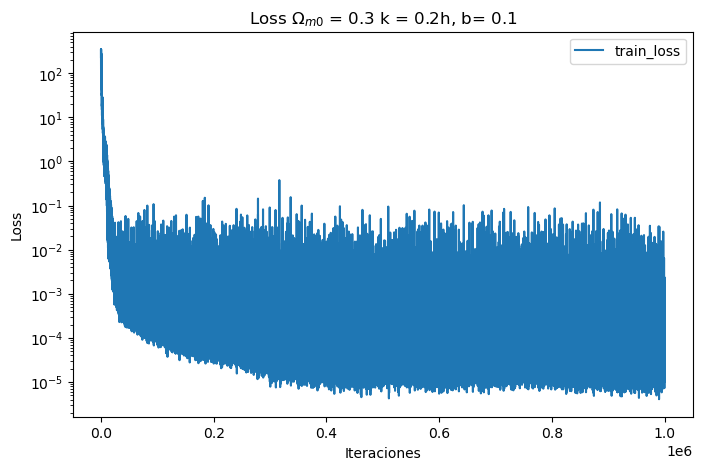

Mejores redes guardadas en: /home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento con H partido redes + numérico/Om = 0.3 k = 0.2, b= 0.1 lr = 0.0001, iteraciones = 1000000, batch_size = 64, (16, 32, 64, 32).pt


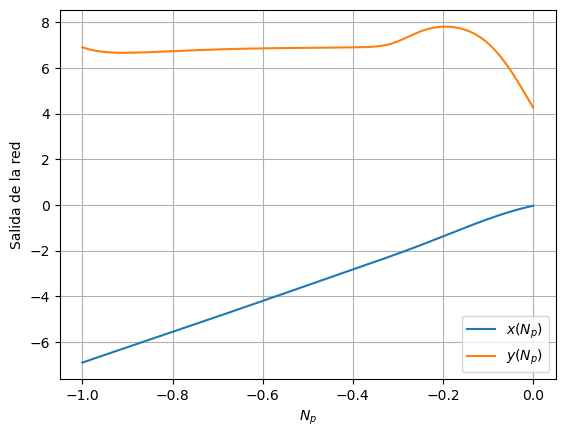

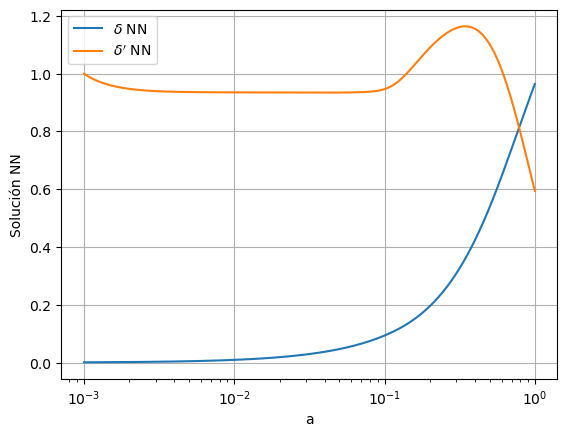

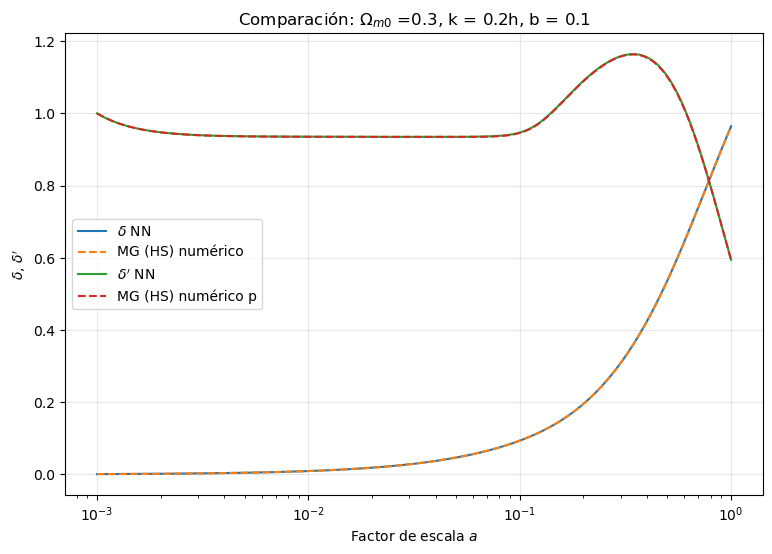

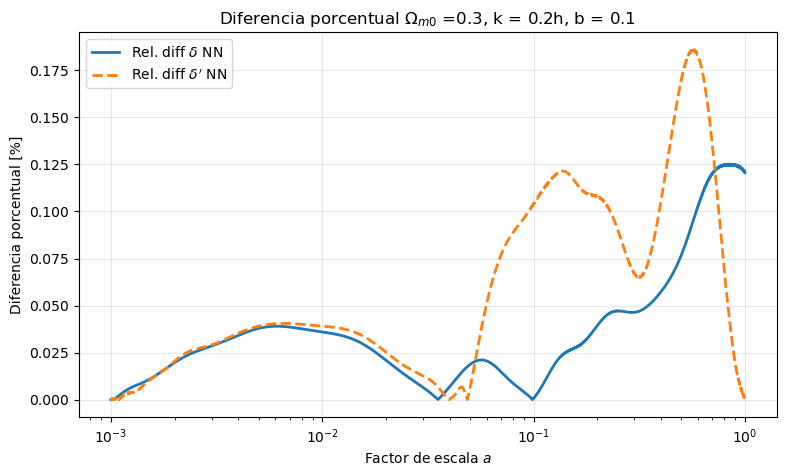

In [ ]:
def ODE_MG_NN(X, X_p, N_p, k_param, Om_m_0, b, H_0, Lambda):
    N = N_p * n_0
    a = torch.exp(N)
    a_flat = a.view(-1)
    a_np = a.detach().cpu().numpy().reshape(-1)
    z_np = (1.0 / a_np) - 1.0
    z_np = np.asarray(z_np, dtype=np.float64)

    mu_np = Geff_G_func(z_np, k_param, b, Om_m_0, Lambda)
    mu_np = np.nan_to_num(mu_np, nan=1.0, posinf=1.0, neginf=1.0)
    mu_np[z_np > z_0] = 1.0
    
    H_z = np.interp(z_np, z_total, H_total, left=H_total[0], right=H_total[-1])
    dHdz = np.interp(z_np, z_total, dH_dz_total, left=dH_dz_total[0], right=dH_dz_total[-1])
    dHda = dHdz * (-1.0 / (a_np ** 2))

    target_device = X_p.device if isinstance(X_p, torch.Tensor) else a.device
    target_dtype  = X_p.dtype   if isinstance(X_p, torch.Tensor) else a.dtype
    np_dt = np.float64 if target_dtype == torch.float64 else np.float32

    H_t = torch.from_numpy(H_z.astype(np_dt)).to(device=target_device, dtype=target_dtype)
    dH_t = torch.from_numpy(dHda.astype(np_dt)).to(device=target_device, dtype=target_dtype)
    mu_t = torch.from_numpy(mu_np.astype(np_dt)).to(device=target_device, dtype=target_dtype)

    denom = (H_t ** 2) * (a_flat ** 3)
    
    term1 = n_0 * ((dH_t / H_t) * a_flat + 2)
    pref = (3 * Om_m_0 * (n_0 ** 2) * (H_0 ** 2)) / 2
    term2 = pref * (mu_t / denom)

    term1_col = term1.unsqueeze(-1)
    term2_col = term2.unsqueeze(-1)

    res1 = diff(X, N_p) - X_p
    res2 = diff(X_p, N_p) + X_p ** 2 + term1_col * X_p - term2_col

    return [res1, res2]

condition = [IVP(N_p_0, -n_0), IVP(N_p_0, n_0)]


def weighted_loss_MG(res, x, t):
    loss = res ** 2
    return loss.mean()


capas = (16, 32, 64, 32)
learning_rate = 1e-4
nets = [FCNN(n_input_units=1, hidden_units=capas) for _ in range(2)]
adam = torch.optim.Adam(set([p for net in nets for p in net.parameters()]), lr=learning_rate)

batch_size = 64
tgz = Generator1D(batch_size, N_p_0, N_p_f) #, 'equally-spaced-noisy')
vgz = Generator1D(batch_size, N_p_0, N_p_f)

train_gen = tgz
valid_gen = vgz

k_eff = k
solver_clase.k = k_eff



solver_nn = Solver1D(
    ode_system = lambda X, X_p, N_hat: ODE_MG_NN(X, X_p, N_hat, k_eff, Om_m_0, b, H_0, Lambda),
    nets = nets,
    n_batches_valid = 0,
    conditions = condition,
    t_min = N_p_0,
    t_max = N_p_f,
    optimizer = adam,
    train_generator = train_gen,
    valid_generator = valid_gen,
    loss_fn = weighted_loss_MG
)

iterations = 1000000
solver_nn.fit(iterations)

nombre_red_1 =f'Om = {Om_m_0} k = {k}, b= {b} lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, {capas}'
save_dir  = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento con H partido redes + numérico"
os.makedirs(save_dir, exist_ok=True)

loss = solver_nn.metrics_history['train_loss']

plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss)), loss, label='train_loss')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.title(f'Loss $\Omega_{{m0}}$ = {Om_m_0} k = {k}h, b= {b}')
plt.savefig(os.path.join(save_dir, f'Loss Om ={Om_m_0}, k = {k}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas}.png'))
plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\O'
<>:88: SyntaxWarning: invalid escape sequence '\O'
<>:77: SyntaxWarning: invalid escape sequence '\O'
<>:88: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_6078/2264034365.py:77: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Comparación: $\Omega_{{m0}}$ ={Om_m_0}, k = {k}h, b = {b}")
/tmp/ipykernel_6078/2264034365.py:88: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Diferencia porcentual $\Omega_{{m0}}$ ={Om_m_0}, k = {k}h, b = {b}")


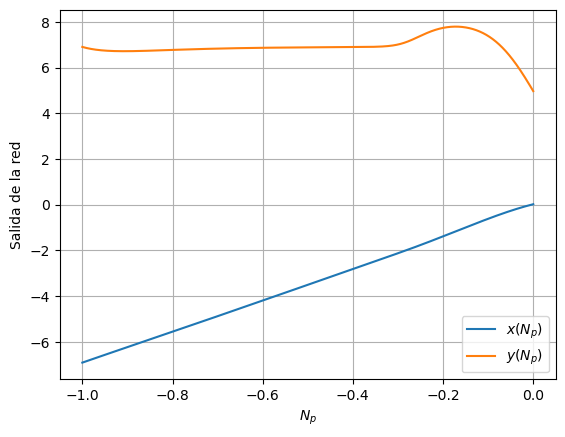

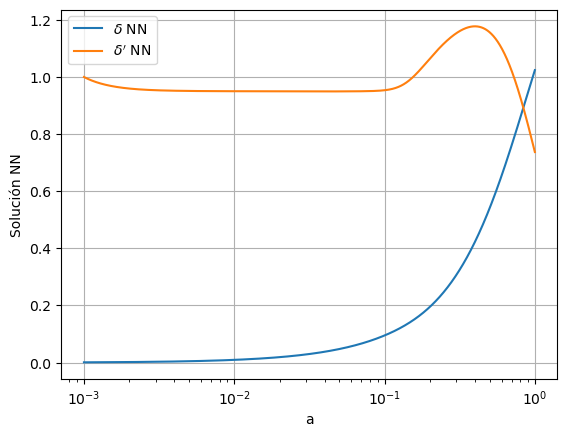

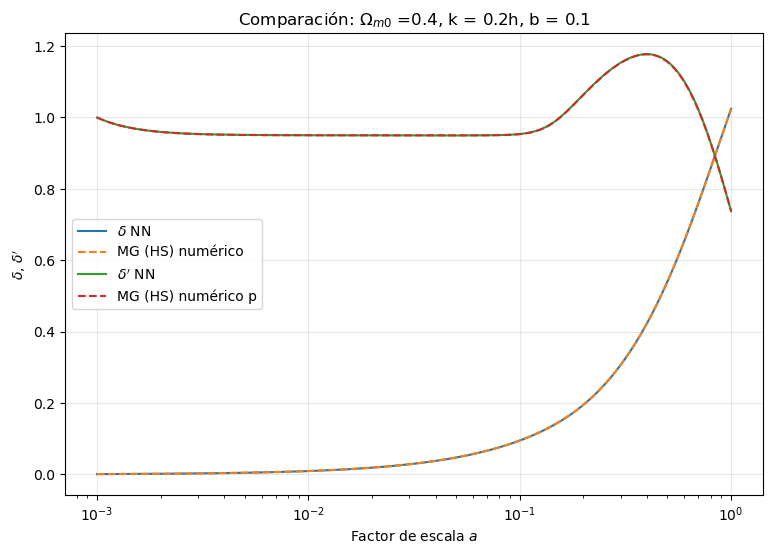

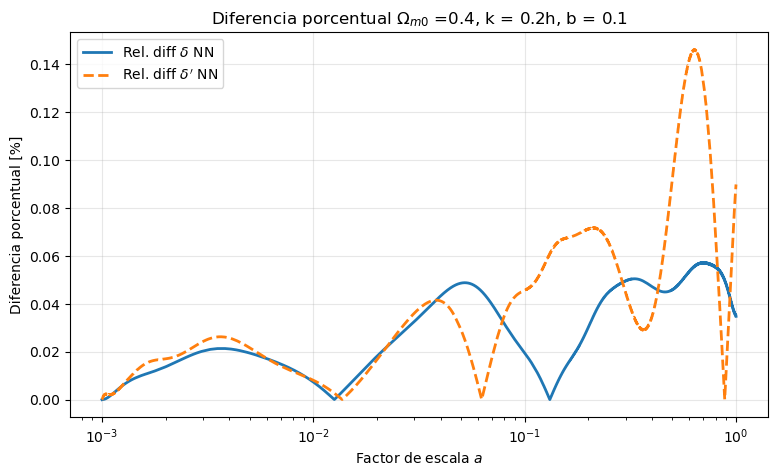

In [ ]:
for net in nets:
    net.eval()

condition = [
    IVP(N_p_0, -n_0),
    IVP(N_p_0,  n_0),
]


sol = Solution1D(nets, condition)


def x_nn(Np_array):
    return sol(Np_array, to_numpy=True)[0]

def y_nn(Np_array):
    return sol(Np_array, to_numpy=True)[1]

Np_vec = np.linspace(N_p_0, N_p_f, 10000).astype(np.float64)  

xN_nb = x_nn(Np_vec)
yN_nb = y_nn(Np_vec)


plt.figure()
plt.plot(Np_vec, xN_nb, label=r'$x(N_p)$')
plt.plot(Np_vec, yN_nb, label=r'$y(N_p)$')
plt.xlabel(r'$N_p$')
plt.ylabel(r'Salida de la red')
plt.legend()
plt.grid(True)

a_vec  = np.exp(n_0 * Np_vec)

delta_nn_nb   = np.exp(xN_nb)
delta_p_nn_nb = delta_nn_nb * yN_nb / (n_0 * a_vec)

N_phys = n_0 * Np_vec
a_phys = np.exp(N_phys)


plt.figure()
plt.plot(a_phys, delta_nn_nb,   label=r'$\delta$ NN')
plt.plot(a_phys, delta_p_nn_nb, label=r'$\delta^\prime$ NN')
plt.xlabel(r'$\hat{N} = \ln{a}$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.xscale('log')
#plt.xlim(0, 0.1)
#plt.ylim(0, 0.1)
plt.xlabel('a')
plt.ylabel('Solución NN')
plt.legend()
plt.grid(True)
plt.show()

num_points = 1000
a_mg, delta_mg, delta_p_mg = solver_clase.solve_delta_mg(num_points=num_points)
delta_mg_interp   = interp1d(a_mg, delta_mg, bounds_error=False, fill_value="extrapolate")
delta_p_mg_interp = interp1d(a_mg, delta_p_mg, bounds_error=False, fill_value="extrapolate")

delta_num = delta_mg_interp(a_phys)
delta_p_num = delta_p_mg_interp(a_phys)

rel_diff_delta   = 100 * np.abs((delta_nn_nb - delta_num) / delta_num)
rel_diff_delta_p = 100 * np.abs((delta_p_nn_nb - delta_p_num) / delta_p_num)

plt.figure(figsize=(9,6))

plt.plot(a_phys, delta_nn_nb, label=r'$\delta$ NN')
plt.plot(a_phys, delta_num, label="MG (HS) numérico", ls="--")
plt.plot(a_phys, delta_p_nn_nb, label=r'$\delta^\prime$ NN')
plt.plot(a_phys, delta_p_num, label="MG (HS) numérico p", ls="--")

plt.xscale("log")
plt.xlabel(r"Factor de escala $a$")
plt.ylabel(r"$\delta$, $\delta^\prime$")
plt.title(f"Comparación: $\Omega_{{m0}}$ ={Om_m_0}, k = {k}h, b = {b}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(save_dir, f"Comparacion Om ={Om_m_0}, k = {k}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas}.png"))
plt.figure(figsize=(9,5))
plt.plot(a_phys, rel_diff_delta, label=r'Rel. diff $\delta$ NN', lw=2)

plt.plot(a_phys, rel_diff_delta_p, label=r'Rel. diff $\delta^\prime$ NN', lw=2, ls='--')
plt.xscale('log')
plt.xlabel("Factor de escala $a$")
plt.ylabel("Diferencia porcentual [%]")
plt.title(f"Diferencia porcentual $\Omega_{{m0}}$ ={Om_m_0}, k = {k}h, b = {b}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(os.path.join(save_dir, f"Diferencia porcentual Om ={Om_m_0}, k = {k}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas}.png"))
plt.show()